<a href="https://colab.research.google.com/github/elkinkazan/itis-2025-cv-course/blob/main/Task1_ImageProcessing_Iliasova_E_11_451.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Студент:
student_first = "Эльвира"    #@param {type:"string"}
student_last  = "Ильясова"  #@param {type:"string"}
student_group = "11-451"  #@param {type:"string"}
assignment_id = "Task1_ImageProcessing"   #@param {type:"string"}

# Дедлайны (ISO-формат предпочтителен: "YYYY-MM-DDTHH:MM±HH:MM" или "YYYY-MM-DD HH:MM")
# Примеры: "2025-09-01T09:00-04:00" или "2025-09-05 23:59"
start_at_iso = "2025-09-14T09:00-04:00"  #@param {type:"string"}
due_at_iso   = "2025-09-29T23:59-04:00"  #@param {type:"string"}

# Для теста можно переопределить момент сдачи (оставьте пустым, чтобы взять текущее время):
submission_time_override = ""            #@param {type:"string"}

from datetime import datetime, timezone

def _parse_dt(s: str):
    s = (s or "").strip()
    if not s:
        return None
    # 1) Пытаемся ISO c offset: YYYY-MM-DDTHH:MM±HH:MM
    try:
        return datetime.fromisoformat(s)
    except Exception:
        pass
    # 2) Пытаемся "YYYY-MM-DD HH:MM"
    for fmt in ("%Y-%m-%d %H:%M", "%Y-%m-%d"):
        try:
            # Если формат без timezone — считаем как UTC, чтобы было детерминировано
            return datetime.strptime(s, fmt).replace(tzinfo=timezone.utc)
        except Exception:
            continue
    raise ValueError(f"Не удалось распарсить дату/время: {s!r}. Используйте ISO, например 2025-09-01T09:00-04:00")

full_name = (student_first.strip() + " " + student_last.strip()).strip()
start_dt = _parse_dt(start_at_iso)
due_dt = _parse_dt(due_at_iso)
submission_dt = _parse_dt(submission_time_override) if submission_time_override.strip() else datetime.now(timezone.utc)

def _sec(td):
    return td.total_seconds()

def penalty_fraction(start_dt, due_dt, now_dt) -> float:
    """
    Доля штрафа за опоздание:
    - До дедлайна: 0
    - После дедлайна: min(1, (now - due) / (due - start))
    - Если окно <= 0: штраф 1 после due, иначе 0
      (то есть после дедлайна всё мгновенно обнуляется).
    """
    if not (start_dt and due_dt and now_dt):
        return 0.0
    window = _sec(due_dt - start_dt)
    if window <= 0:
        return 1.0 if now_dt > due_dt else 0.0
    late = max(0.0, _sec(now_dt - due_dt))
    return min(1.0, late / window)

pf = penalty_fraction(start_dt, due_dt, submission_dt)

print("Студент:", full_name, "| Группа:", student_group, "| ID:", assignment_id)
print("Окно сдачи: ", start_dt, "→", due_dt)
print("Момент сдачи:", submission_dt)
print(f"Penalty fraction (доля штрафа): {pf:.4f}  (0 — нет, 1 — обнуление)")
score = 0
max_score = 15

Студент: Эльвира Ильясова | Группа: 11-451 | ID: Task1_ImageProcessing
Окно сдачи:  2025-09-14 09:00:00-04:00 → 2025-09-29 23:59:00-04:00
Момент сдачи: 2025-09-29 09:00:38.899793+00:00
Penalty fraction (доля штрафа): 0.0000  (0 — нет, 1 — обнуление)


In [ ]:
# MAIN NOTEBOOK GOES HERE
# DO NOT MODIFY  !!!
# DO NOT EXECUTE !!!
task_id = "Task1_ImageProcessing"
score = 0
max_score = 15

In [ ]:
!pip install imutils

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv2
from skimage import io
from PIL import Image
import matplotlib.pylab as plt
from skimage.transform import pyramid_gaussian
import imutils

In [ ]:
image = io.imread("https://www.wfla.com/wp-content/uploads/sites/71/2023/05/GettyImages-1389862392.jpg?w=2560&h=1440&crop=1")
image_2 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
final_frame = cv2.hconcat((image, image_2))
image[100,100] = [255,255,255]
print( image[100,100] )

[255 255 255]


# Linear filtering blurring the image

Question why source image size the same? use matrix represntation to study it.

(0.0, 256.0)

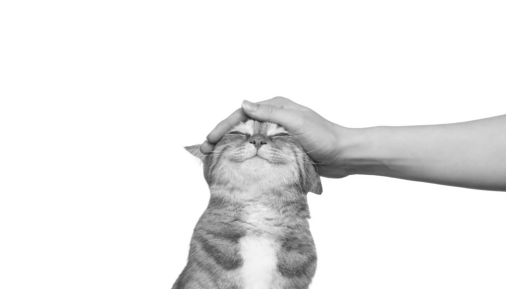

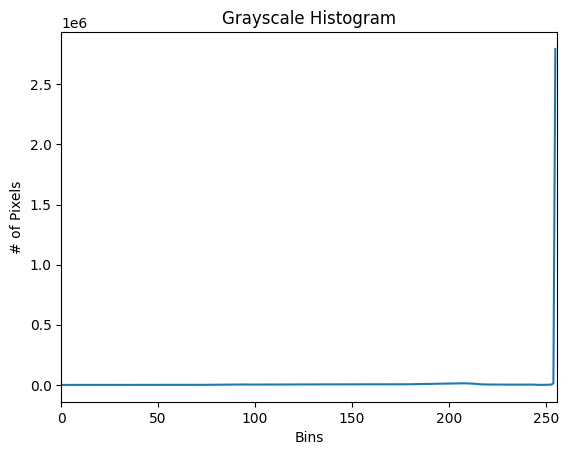

In [ ]:
image2 = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([image2], [0], None, [256], [0, 256])
# matplotlib expects RGB images so convert and then display the image
# with matplotlib
plt.figure()
plt.axis("off")
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_GRAY2RGB))
# plot the histogram
plt.figure()
plt.title("Grayscale Histogram")
plt.xlabel("Bins")
plt.ylabel("# of Pixels")
plt.plot(hist)
plt.xlim([0, 256])

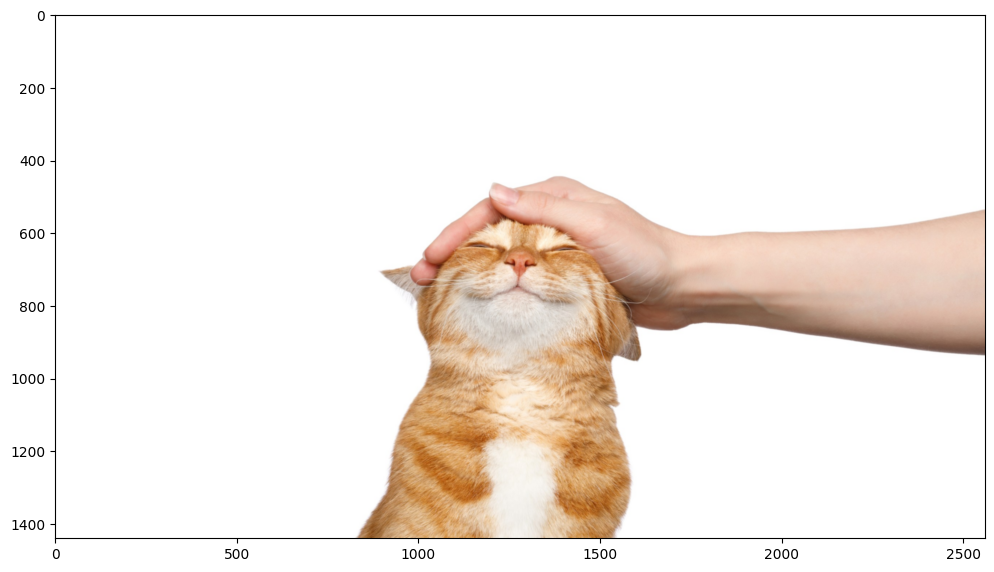

In [ ]:
kernel = np.ones((3, 3), np.float32) / 9
img = cv2.filter2D(image, -1, kernel)
fig, ax = plt.subplots(1, figsize=(12,8))

plt.imshow(img)


# Task 1. Implement non linear filters -- median and bilateral

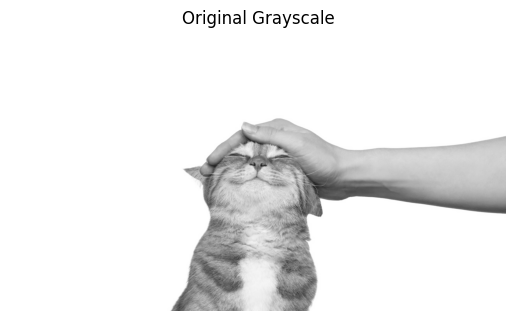

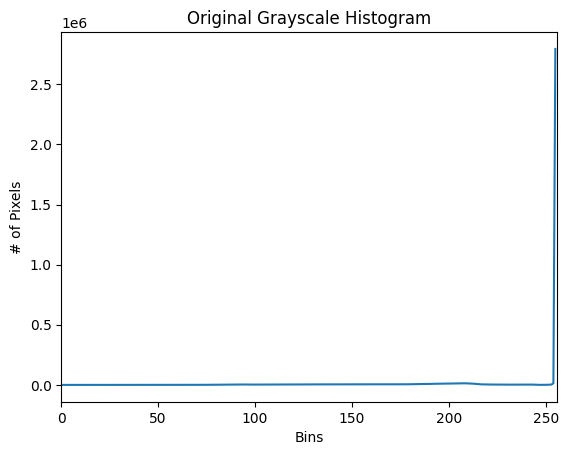

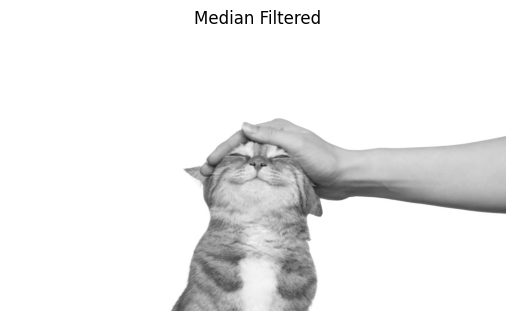

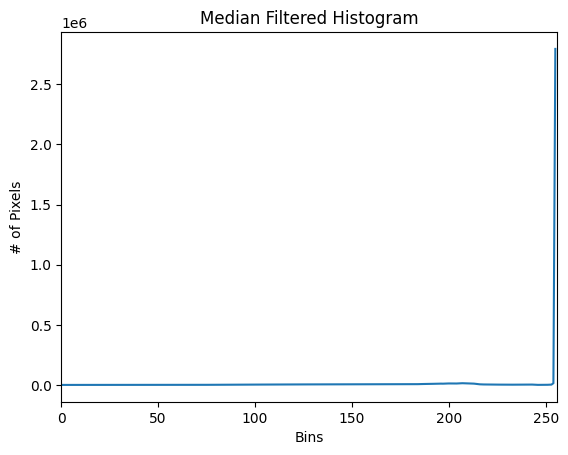

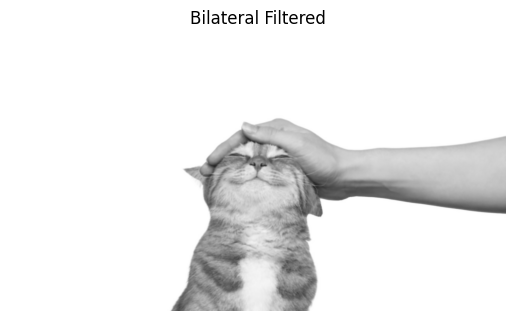

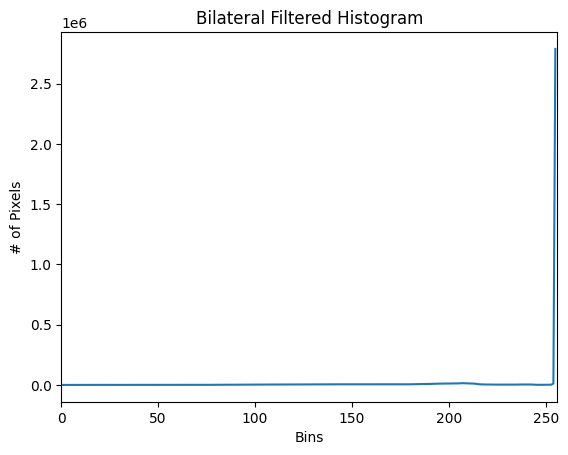

In [ ]:

# Предположим, у тебя есть исходное изображение
image3 = image  # замените на путь к вашему изображению

# Переводим в оттенки серого
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def apply_median_filter(gray_image, ksize=5):
    """
    Применяет медианный фильтр к изображению в оттенках серого.
    """
    # YOU CODE HERE 1 line
    return cv2.medianBlur(gray_image, ksize)

def apply_bilateral_filter(gray_image, d=9, sigmaColor=75, sigmaSpace=75):
    """
    Применяет билатеральный фильтр к изображению в оттенках серого.
    """
    # YOU CODE HERE1 1 line
    return cv2.bilateralFilter(gray_image, d, sigmaColor, sigmaSpace)

# --- Median Filter ---
median = apply_median_filter(gray, 5)  # ядро 5x5

# --- Bilateral Filter ---
bilateral = apply_bilateral_filter(gray, d=9, sigmaColor=75, sigmaSpace=75)

# Функция для показа изображения и гистограммы
def show_image_and_hist(img, title):
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])

    plt.figure()
    plt.axis("off")
    plt.title(title)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))

    plt.figure()
    plt.title(f"{title} Histogram")
    plt.xlabel("Bins")
    plt.ylabel("# of Pixels")
    plt.plot(hist)
    plt.xlim([0, 256])

# Показываем оригинал и фильтрованные изображения
show_image_and_hist(gray, "Original Grayscale")
show_image_and_hist(median, "Median Filtered")
show_image_and_hist(bilateral, "Bilateral Filtered")

plt.show()

In [ ]:
import unittest
import cv2
import numpy as np

class TestImageFilters(unittest.TestCase):
    def setUp(self):

        self.gray = image3
        if self.gray is None:
            raise FileNotFoundError("Изображение не найдено")

    def test_median_filter_changes_image(self):
        filtered = apply_median_filter(self.gray)
        diff = cv2.absdiff(self.gray, filtered)
        self.assertGreater(np.count_nonzero(diff), 0, "Median filter did not change the image")
        global score
        score=score+2.5

    def test_bilateral_filter_changes_image(self):
        filtered = apply_bilateral_filter(self.gray)
        diff = cv2.absdiff(self.gray, filtered)
        self.assertGreater(np.count_nonzero(diff), 0, "Bilateral filter did not change the image")
        global score
        score=score+2.5

# Run unit tests
if __name__ == "__main__":
    unittest.main(argv=['first-arg-is-ignored'], exit=False)
    print(f"Student Score: {score}/{max_score}")


..
----------------------------------------------------------------------
Ran 2 tests in 0.999s

OK


Student Score: 5.0/15


# Fourier transform
У Numpy есть программный пакет FFT для выполнения этой операции.np.fft.fft2() предоставляет нам преобразование частоты, которое будет сложным массивом.

как только результат будет получен, нулевая частотная составляющая (составляющая постоянного тока) будет в верхнем левом углу.

Если вы хотите центрировать его, вам нужно переместить результат $ frac {N} {2} $ в обоих направлениях. Просто передайте функциюnp.fft.fftshift() завершить. (Проще анализировать).

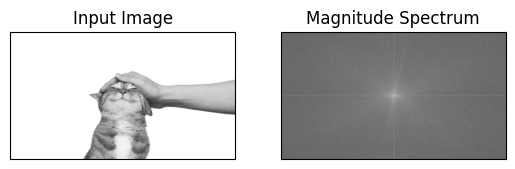

In [ ]:
# use gray image

f = np.fft.fft2(image2) # 2 dimensional discrete fourier transform
fshift = np.fft.fftshift(f) # shift zero frequenct component to the center of spectrum
magnitude_spectrum = 20*np.log(np.abs(fshift))
plt.subplot(121),plt.imshow(image2, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

Теперь вы можете выполнять некоторые операции в частотной области, такие как фильтрация верхних частот и реконструкция изображения, то есть найти обратное ДПФ. Для этого вам нужно всего лишь использовать прямоугольную оконную маску 60x60 для устранения низких частот. Затем используйтеnp.fft.ifftshift() Примените обратный сдвиг, чтобы компонент постоянного тока снова появился в верхнем левом углу. Затем используйтеnp.ifft2Функция () находит обратное БПФ. Опять же, результатом будет комплексное число. Вы можете использовать его абсолютное значение.

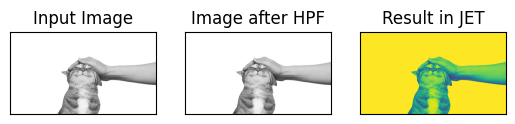

In [ ]:
img= image2
rows, cols = img.shape
crow,ccol = rows//2 , cols//2
fshift[crow-30:crow-31, ccol-30:ccol-31] = 0
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.real(img_back)
plt.subplot(131),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after HPF'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(img_back)
plt.title('Result in JET'), plt.xticks([]), plt.yticks([])
plt.show()

🧠 Теория: Почему это фильтры высоких частот?
Высокие частоты в изображении — это резкие переходы, например, границы объектов.

Низкие частоты — это плавные изменения (фон, тело кошки).

🔹 Laplacian
Это вторая производная — усиливает места, где происходит резкое изменение интенсивности.

В Фурье-пространстве — умножает спектр на
(
𝑢
2
+
𝑣
2
)
(u
2
 +v
2
 ), что подавляет низкие частоты и усиливает высокие.

🔹 Sobel
Это производная по X и Y направлениям, с легким сглаживанием. Также акцентирует внимание на границах — то есть высоких частотах.

🔹 Scharr
Это улучшенный Sobel, особенно устойчивый к шуму и точнее выделяющий границы — но всё равно, это градиент, а значит — фильтр высоких частот.

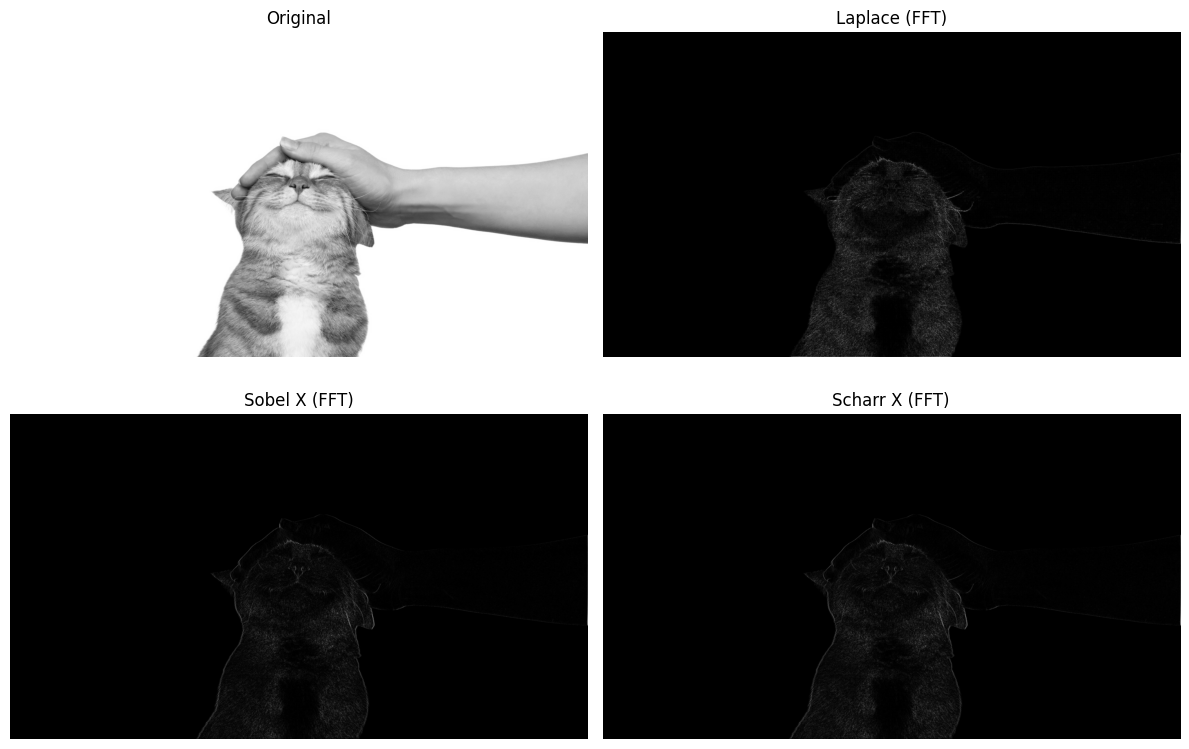

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def pad_kernel_to_image(kernel, shape):
    """Расширяет ядро до размера изображения с нулями (zero-padding)."""
    padded = np.zeros(shape, dtype=np.float32)
    kh, kw = kernel.shape
    padded[:kh, :kw] = kernel
    padded = np.roll(padded, -kh//2, axis=0)  # центрируем ядро
    padded = np.roll(padded, -kw//2, axis=1)
    return padded

def filter_fft(image, kernel):
    """Применяет фильтрацию через преобразование Фурье."""
    image = np.float32(image)

    # Переход в частотную область
    dft_image = np.fft.fft2(image)

    # Подготовка фильтра
    kernel_padded = pad_kernel_to_image(kernel, image.shape)
    dft_kernel = np.fft.fft2(kernel_padded)

    # Перемножение в частотной области
    filtered_freq = dft_image * dft_kernel

    # Обратное преобразование
    result = np.fft.ifft2(filtered_freq)
    result = np.abs(result)
    return result

# Загрузка и преобразование изображения
image = image2

# Ядра фильтров
laplacian_kernel = np.array([[0, 1, 0],
                             [1, -4, 1],
                             [0, 1, 0]], dtype=np.float32)

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

scharr_x = np.array([[-3, 0, 3],
                     [-10, 0, 10],
                     [-3, 0, 3]], dtype=np.float32)

# Применим фильтры через частотную область
laplace_result = filter_fft(image, laplacian_kernel)
sobel_result = filter_fft(image, sobel_x)
scharr_result = filter_fft(image, scharr_x)

# Визуализация
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Laplace (FFT)")
plt.imshow(laplace_result, cmap='gray')
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Sobel X (FFT)")
plt.imshow(sobel_result, cmap='gray')
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Scharr X (FFT)")
plt.imshow(scharr_result, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


Чтобы получить именно границы изображения через частотную фильтрацию, нужно:

✅ Суть
Границы — это высокочастотные компоненты изображения.

Значит, нужно








*  Перейти в частотную область (FFT).
*  Подавить низкие частоты (центр спектра).
*  Оставить высокие частоты (периферию спектра).
*  Сделать обратное FFT, чтобы получить изображение границ.




In [ ]:
import cv2
import numpy as np

def extract_edges_fft(image_gray: np.ndarray, radius: int = 50) -> np.ndarray:
    """
    Выделяет границы изображения через подавление низких частот в спектре.

    :param image_gray: входное изображение в оттенках серого
    :param radius: радиус центральной области, которую нужно подавить (низкие частоты)
    :return: изображение границ
    """
    h, w = image_gray.shape

    # FFT + сдвиг центра спектра

    f = np.fft.fft2(image_gray)
    fshift = np.fft.fftshift(f)

    # Маска высоких частот
    # creates mask with filled with 1
    # YOU CODE STARTS HERE  2 lines
    mask = np.ones((h, w), dtype=np.uint8)
    # prepare the circle for radius
    cy, cx = h // 2, w // 2
    cv2.circle(mask, (cx, cy), radius, 0, -1)
    # YOU CODE ENDS HERE

    # YOU CODE STARTS HERE  1 line
    # Применение маски
    f_filtered = fshift * mask
    # YOU CODE ENDS HERE

    # Обратное преобразование
    f_ishift = np.fft.ifftshift(f_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    # Нормализация до uint8
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
    return img_back.astype(np.uint8)


In [ ]:
import numpy as np

def count_white_pixels(image_gray: np.ndarray, threshold: int = 0) -> int:
    """
    Считает количество чёрных пикселей в изображении (значение <= threshold).

    :param image_gray: изображение в оттенках серого (dtype = np.uint8)
    :param threshold: порог, ниже или равным которому пиксели считаются чёрными
    :return: количество чёрных пикселей
    """
    return np.sum(image_gray >= threshold)


In [ ]:
import unittest
import cv2
import numpy as np

class TestImageFilters(unittest.TestCase):
    def setUp(self):

        self.gray = image3
        if self.gray is None:
            raise FileNotFoundError("Изображение не найдено")

    def test_fft_edge_detection(self):
        # Загрузка изображения
        global image2
        img = image2

        white_pixels = count_white_pixels(img, threshold=200)

        edges = extract_edges_fft(img, radius=50)
        white_pixels = count_white_pixels(edges, threshold=200)
        self.assertGreater(white_pixels, 5, "FFT Edge Detection did not detect edges")
        self.assertLessEqual(white_pixels, 100, "FFT Edge Detection did not detect edges")
        global score
        score=score+10

# Run unit tests
if __name__ == "__main__":
    unittest.main(argv=['first-arg-is-ignored'], exit=False)
    print(f"Student Score: {score}/{max_score}")

.
----------------------------------------------------------------------
Ran 1 test in 0.432s

OK


Student Score: 15.0/15


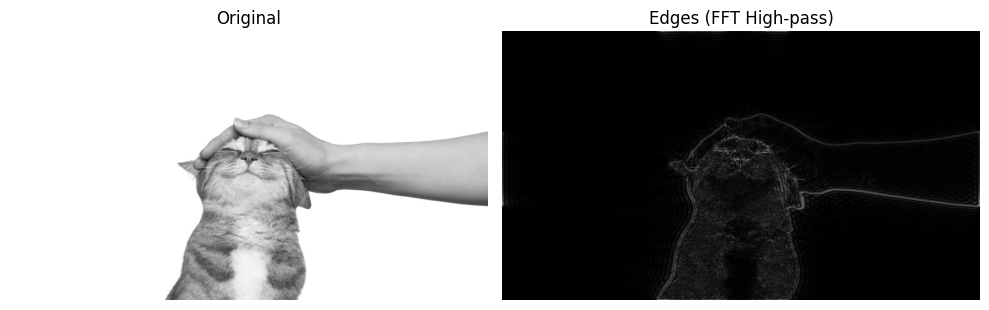

In [ ]:
import matplotlib.pyplot as plt

# Загрузка изображения
img = image2

# Применение функции
edges = extract_edges_fft(img, radius=50)
# Отображение
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Edges (FFT High-pass)")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
max_points = max_score
raw_score = score

# применяем штраф
try:
    pf = penalty_fraction(start_dt, due_dt, submission_dt)
except NameError:
    # если кто-то запустил автопроверку до ячейки с дедлайнами
    from datetime import timezone
    pf = 0.0

final_score = max(0.0, raw_score * (1.0 - min(1.0, pf)))

print(f"Сырой балл: {raw_score}/{max_points}")
print(f"Штраф (доля): {pf:.4f}")
print(f"Итоговый балл после штрафа: {final_score:.2f}/{max_points}")

# Последняя строка — JSON, который читает harness
final = {
    "name": full_name,
    "group": student_group,
    "assignment": assignment_id,
    "score": float(final_score)
}


Сырой балл: 15.0/15
Штраф (доля): 0.0000
Итоговый балл после штрафа: 15.00/15


In [ ]:
import json
import numpy as np
from datetime import datetime, timezone
print(json.dumps(final, ensure_ascii=False))

{"name": "Эльвира Ильясова", "group": "11-451", "assignment": "Task1_ImageProcessing", "score": 15.0}
